In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent.parent))

import mesmer
import model
import model_analysis

import matplotlib.pyplot as plt
import xarray as xr

import cartopy.crs as ccrs



In [2]:
is_local_data = False
Month_idx = 4
safe = True
start = None
end = None
max_depth = 3

### Load parameters of the transformations

In [3]:
transform_keys = ["none","log","logit","rel"]

In [4]:
parameter_sets = {}
for key in transform_keys:
    parameter_sets[f"{key}_transform"] = model.loading.load_params(var = "mrsol",scen= "historical", folder = f"MPI-ESM1-2-LR/variations/Transformation_Distribution/{key}_transform/local{is_local_data}/month{Month_idx}", name=f"start={start},end={end}.max_depth{max_depth}")

the mask should only change if one is based on relative data, and one is abs because the threshold has a different effect

In [5]:
print(parameter_sets["logit_transform"]["detail_mask"].equals(parameter_sets["rel_transform"]["detail_mask"]))
print(parameter_sets["none_transform"]["detail_mask"].equals(parameter_sets["log_transform"]["detail_mask"]))

True
True


In [6]:
print(parameter_sets["none_transform"]["chunk_mask"].equals(parameter_sets["log_transform"]["chunk_mask"]))
print(parameter_sets["none_transform"]["chunk_mask"].equals(parameter_sets["logit_transform"]["chunk_mask"]))
print(parameter_sets["none_transform"]["chunk_mask"].equals(parameter_sets["rel_transform"]["chunk_mask"]))


True
True
True


In [7]:
chunk_mask = parameter_sets["none_transform"]["chunk_mask"]
abs_detal_mask = parameter_sets["none_transform"]["detail_mask"]
rel_detal_mask = parameter_sets["rel_transform"]["detail_mask"]

### Load test input

In [8]:
run_idx = 4

tas_ds = model.loading.load_data_set(var = "tas", local = is_local_data, run_idx=run_idx)
pr_ds = model.loading.load_data_set(var = "pr", local = is_local_data, run_idx=run_idx)
tas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=Month_idx)
pr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=Month_idx)

raw_input_for_test = xr.merge([tas_ds,pr_ds]).drop_vars("file_qf")


### shape inputs

In [9]:
def shape_input(ds, chunk_mask):
    ds = ds.sel(time=slice(start, end)).resample(time="ME").mean()
    ds = ds.sel(time= ds.time.dt.month == Month_idx)
    ds = model.mask.mask_mask(ds,chunk_mask)
    ds = mesmer.grid.stack_lat_lon(ds)
    return ds


In [10]:
inputs = {}
for key in transform_keys:
    inputs[key] = shape_input(raw_input_for_test, parameter_sets[f"{key}_transform"]["chunk_mask"].mrsol)

### Emulate

In [11]:
predictions = {}

In [12]:
for t_key in transform_keys:
    for m_key in ["mean","variance","skew"]:
        if m_key == "skew" and t_key in ["none", "rel"]:
            break
        LinReg = model.stats._parallel_linear_regression.ParLinearRegression()
        LinReg = LinReg.from_params(parameter_sets[f"{t_key}_transform"][m_key])
        if m_key == "skew":
            predictions[f"{t_key}_{m_key}"] = LinReg.predict(inputs[t_key]).transpose("gridcell","time", "depth").clip(min=-0.995,max=0.995)
        if m_key == "variance":
            predictions[f"{t_key}_{m_key}"] = LinReg.predict(inputs[t_key]).transpose("gridcell","time", "depth").clip(min=1e-32)
        else:
            predictions[f"{t_key}_{m_key}"] = LinReg.predict(inputs[t_key]).transpose("gridcell","time", "depth")

maximas

In [13]:
rel_maximas_da = model.mask.mask_mask(parameter_sets["rel_transform"]["local_maximas"],parameter_sets["rel_transform"]["chunk_mask"].mrsol).isel(depth=slice(0, max_depth))
rel_maximas_da = mesmer.grid.stack_lat_lon(rel_maximas_da).drop_vars("depth_bnds").transpose("gridcell","depth").mrsol

logit_maximas_da = model.mask.mask_mask(parameter_sets["logit_transform"]["local_maximas"],parameter_sets["logit_transform"]["chunk_mask"].mrsol).isel(depth=slice(0, max_depth))
logit_maximas_da = mesmer.grid.stack_lat_lon(logit_maximas_da).drop_vars("depth_bnds").transpose("gridcell","depth").mrsol


### load and shape target

In [14]:
def shape_target(ds):
    #ds = ds.clip(min = 1e-32)
    ds = ds.sel(time=slice(start, end)).resample(time="ME").mean()
    ds = ds.sel(time= ds.time.dt.month == Month_idx).isel(depth=slice(0, max_depth)).drop_vars("depth_bnds")
    return ds

In [15]:
def mask_stack_target(ds):
    masked_ds, chunk_mask, detail_mask= model.mask.mask_nonpositiv_height_chunks(ds)
    ds = mesmer.grid.stack_lat_lon(masked_ds)
    ds = ds.transpose("gridcell","time", "depth")
    return ds

In [16]:
raw_mrsol_for_test = model.loading.load_data_set(var = "mrsol", local = is_local_data, run_idx=run_idx)

In [17]:
target_unstacked = shape_target(raw_mrsol_for_test)
target = mask_stack_target(target_unstacked)

#### Scores

In [18]:
score_sets = {}


In [19]:
score_keys = ["beta","gamma","norm_log","norm_logit","skew_log","skew_logit"]

In [20]:
score_sets["beta"] = model_analysis.crps_score.crps_beta_score(predictions["rel_mean"],predictions["rel_variance"], target, transformation = "rel", maximas_da = rel_maximas_da,ensemble_size = 15)

In [21]:
score_sets["gamma"] = model_analysis.crps_score.crps_gamma_score(predictions["none_mean"].clip(min = 1e-32),predictions["none_variance"], target, transformation = None, ensemble_size = 15)

In [22]:
score_sets["norm_log"] = model_analysis.crps_score.crps_norm_score(predictions["log_mean"],predictions["log_variance"], target, transformation = "Log", ensemble_size = 15)

In [23]:
score_sets["norm_logit"] = model_analysis.crps_score.crps_norm_score(predictions["logit_mean"],predictions["logit_variance"], target, transformation = "Logit", maximas_da = logit_maximas_da,ensemble_size = 15)

In [24]:
score_sets["skew_log"] = model_analysis.crps_score.crps_skew_score(predictions["log_mean"],predictions["log_variance"],predictions["log_skew"], target, transformation = "Log",ensemble_size = 15)

In [25]:
score_sets["skew_logit"] = model_analysis.crps_score.crps_skew_score(predictions["logit_mean"],predictions["logit_variance"],predictions["logit_skew"], target, transformation = "Logit",maximas_da = logit_maximas_da,ensemble_size = 15)

In [26]:
for s_keys, scores in score_sets.items():
    score_sets[s_keys] = mesmer.grid.unstack_lat_lon_and_align(scores, target_unstacked)
    if s_keys in ["beta","norm_logit","skew_logit"]:
        score_sets[s_keys] = model.mask.mask_mask(score_sets[s_keys],rel_detal_mask.mrsol,"lon", "lat", "depth")
    else:
        score_sets[s_keys] = model.mask.mask_mask(score_sets[s_keys],abs_detal_mask.mrsol,"lon", "lat", "depth")

In [27]:
all_scores_ds = xr.Dataset({key : score.crps_score for key, score in score_sets.items()})

In [28]:
if safe:
    model.save.save_crps_scores(all_scores_ds, var = "mrsol",scen= "historical", folder = f"MPI-ESM1-2-LR/variations/Transformation_Distribution/all_scores/local{is_local_data}/month{Month_idx}", name=f"start={start},end={end}.max_depth{max_depth}")

In [36]:
table = all_scores_ds.mean(dim=["lon","lat","time"]).to_pandas().T
latex = table.to_latex(
     float_format="%.3f",
     caption="mean CRPS for different histery",
     label="tab:crpss"
)
latex

'\\begin{table}\n\\caption{mean CRPS for different histery}\n\\label{tab:crpss}\n\\begin{tabular}{lrrr}\n\\toprule\ndepth & 0.030000 & 0.190000 & 0.780000 \\\\\n\\midrule\nbeta & 0.428 & 1.657 & 6.761 \\\\\ngamma & 0.426 & 1.659 & 6.779 \\\\\nnorm_log & 0.450 & 1.671 & 6.803 \\\\\nnorm_logit & 0.418 & 1.641 & 6.718 \\\\\nskew_log & 0.450 & 1.677 & 6.805 \\\\\nskew_logit & 0.420 & 1.648 & 6.746 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n'

In [29]:
all_scores_ds.mean(dim=["lon","lat","time"])

<xarray.Dataset> Size: 168B
Dimensions:     (depth: 3)
Coordinates:
  * depth       (depth) float64 24B 0.03 0.19 0.78
Data variables:
    beta        (depth) float64 24B 0.4277 1.657 6.761
    gamma       (depth) float64 24B 0.4262 1.659 6.779
    norm_log    (depth) float64 24B 0.4501 1.671 6.803
    norm_logit  (depth) float64 24B 0.4176 1.641 6.718
    skew_log    (depth) float64 24B 0.4505 1.677 6.805
    skew_logit  (depth) float64 24B 0.4201 1.648 6.746

The normal distribution on the logit data is selected with scores of: 0.4178 1.642 6.723

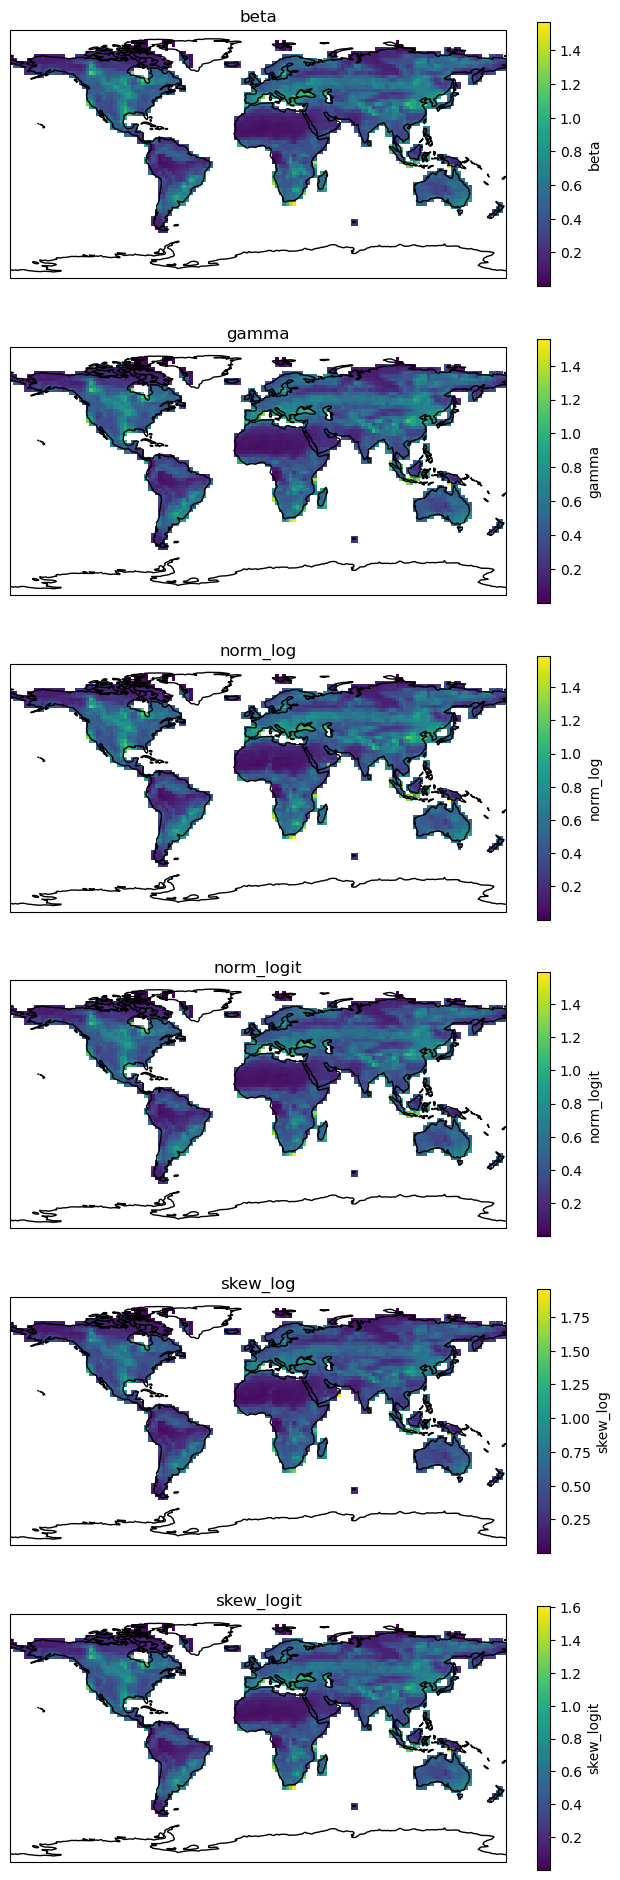

In [30]:
fig_global_crpss, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=6,
    ncols=1,
    figsize=(8, 24)
)
depth = 0

for i, s_key in enumerate(score_keys):
    da = all_scores_ds.isel(depth=depth).mean("time")[s_key]
    da.plot(ax=ax[i])
    ax[i].coastlines()
    ax[i].set_title(s_key)



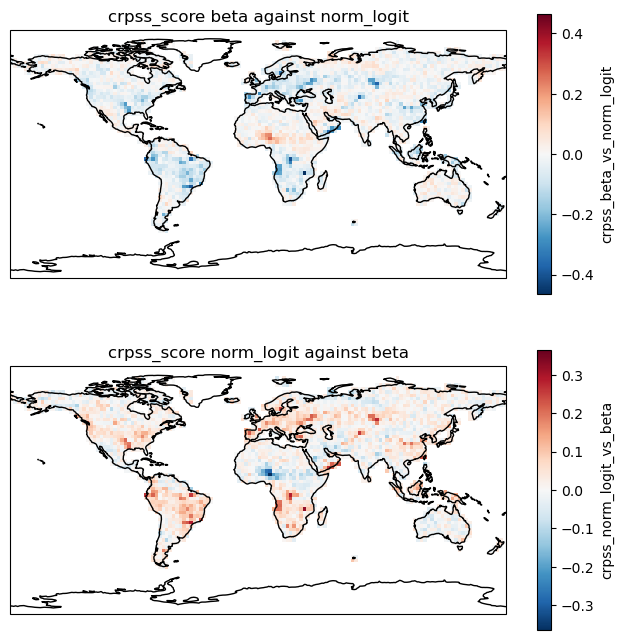

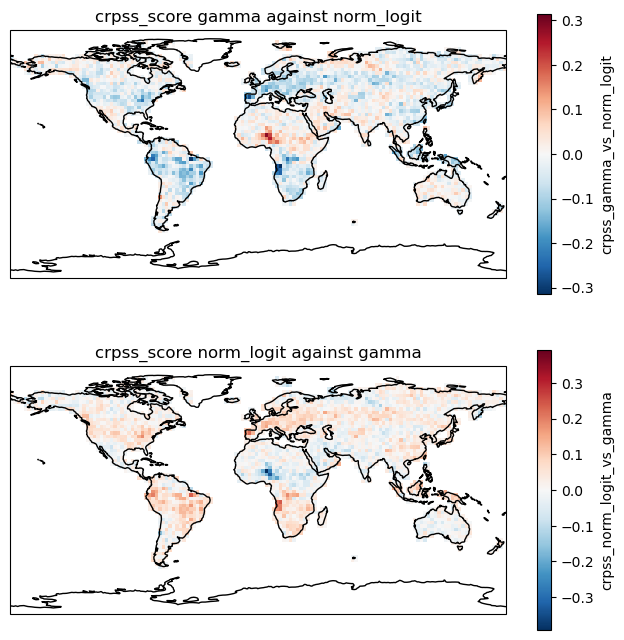

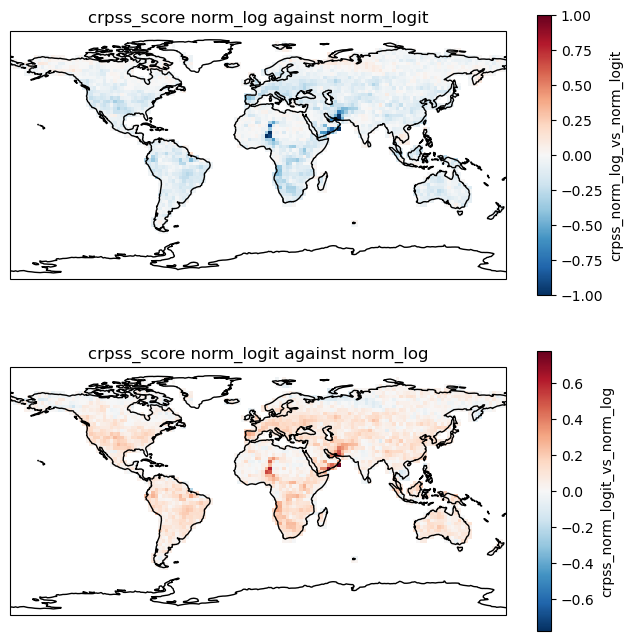

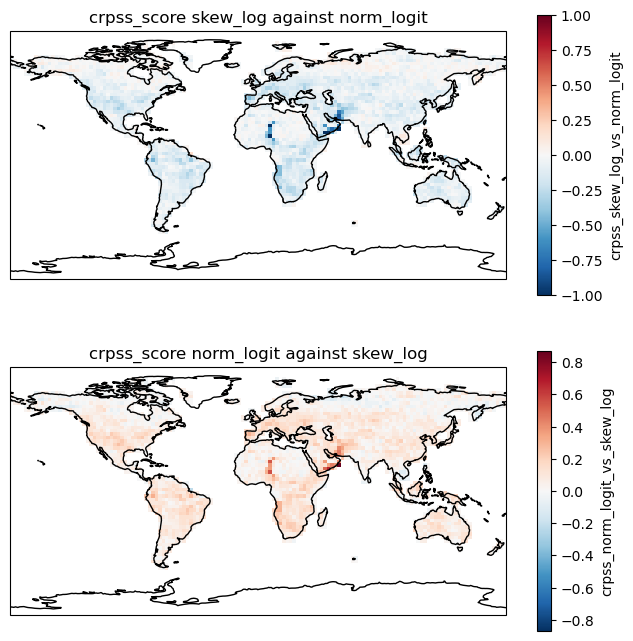

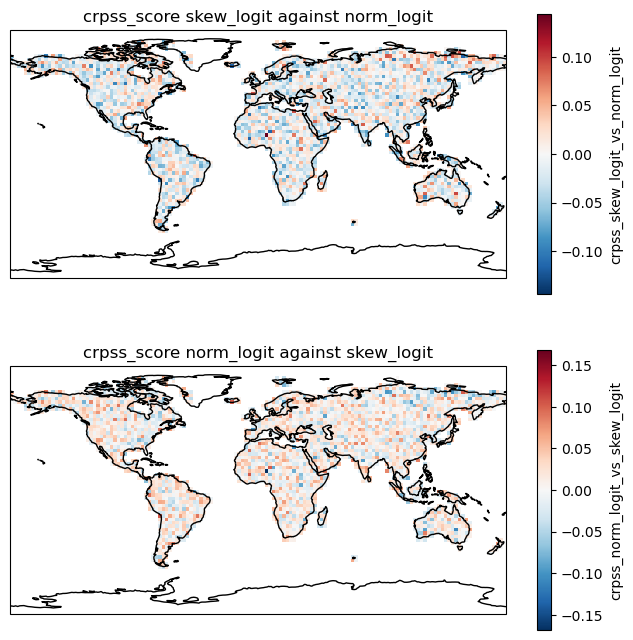

In [31]:
depth = 0

choice = "norm_logit"

for i, s_key in enumerate(score_keys):
    if s_key == choice:
        continue
    vs = model_analysis.crps_score.combine_two_crps_and_the_crpss(score_sets[choice].crps_score,score_sets[s_key].crps_score,choice,s_key)

    fig_global_crpss, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=2,
    ncols=1,
    figsize=(8, 8)
    )

    """
    da = vs.isel(depth=depth).mean("time")[s_key]
    da.plot(ax=ax[0])
    ax[0].coastlines()
    ax[0].set_title(s_key)

    da = vs.isel(depth=depth).mean("time")[choice]
    da.plot(ax=ax[1])
    ax[1].coastlines()
    ax[1].set_title(choice)
    """
    da = vs.isel(depth=depth)[f"crpss_{s_key}_vs_{choice}"].clip(min=-1)
    da.plot(ax=ax[0])
    ax[0].coastlines()
    ax[0].set_title(f"crpss_score {s_key} against {choice}")

    da = vs.isel(depth=depth)[f"crpss_{choice}_vs_{s_key}"].clip(min=-1)
    da.plot(ax=ax[1])
    ax[1].coastlines()
    ax[1].set_title(f"crpss_score {choice} against {s_key}")

    fig_global_crpss.show()
    if safe:
        model.save.save_plot(fig_global_crpss, var = "mrsol",scen= "historical", folder = f"MPI-ESM1-2-LR/variations/Transformation_Distribution/{s_key}_against_{choice}/local{is_local_data}/month{Month_idx}", name=f"start={start},end={end},depth{depth}")
        


In [32]:
target_unstacked

<xarray.Dataset> Size: 41MB
Dimensions:  (time: 165, depth: 3, lat: 72, lon: 144)
Coordinates:
  * time     (time) datetime64[ns] 1kB 1850-04-30 1851-04-30 ... 2014-04-30
  * depth    (depth) float64 24B 0.03 0.19 0.78
  * lat      (lat) float64 576B -88.75 -86.25 -83.75 ... 83.75 86.25 88.75
  * lon      (lon) float64 1kB 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
Data variables:
    mrsol    (time, depth, lat, lon) float64 41MB 0.0 0.0 0.0 ... nan nan nan
Attributes: (12/52)
    CDI:                       Climate Data Interface version 1.9.6 (http://m...
    history:                   Mon Mar 01 09:46:33 2021: cdo -O -b F64 -remap...
    source:                    MPI-ESM1.2-LR (2017): \naerosol: none, prescri...
    institution:               Max Planck Institute for Meteorology
    Conventions:               CF-1.7 CMIP-6.2
    activity_id:               CMIP
    ...                        ...
    cmor_version:              3.5.0
    tracking_id:               hdl:21.14100/46bd6c3e-3b17-48d0-8982-8ab845551535
    cmip6-ng:                  \ncontact = cmip6-archive@env.ethz.ch\ndescrip...
    original_file_names:       /net/atmos/data/cmip6/historical/Emon/mrsol/MP...
    original_file_hash_codes:  bb3e211b9851b5ac90608e41dec61cf0402900efdabe49...
    CDO:                       Climate Data Operators version 1.9.6 (http://m...

In [33]:
max_unstacked = mesmer.grid.unstack_lat_lon_and_align(rel_maximas_da, target_unstacked.isel(time=0))

In [34]:
(target_unstacked.mean("time")["mrsol"]/max_unstacked).isel(depth=depth)

<xarray.DataArray 'mrsol' (lat: 72, lon: 144)> Size: 83kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(72, 144))
Coordinates:
  * lat      (lat) float64 576B -88.75 -86.25 -83.75 ... 83.75 86.25 88.75
  * lon      (lon) float64 1kB 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
    depth    float64 8B 0.03
    time     datetime64[ns] 8B 1850-04-30
Attributes:
    standard_name:  mass_content_of_water_in_soil_layer
    long_name:      Total Water Content of Soil Layer
    units:          kg m-2
    comment:        in each soil layer, the mass of water in all phases, incl...
    original_name:  mrsol
    cell_methods:   area: mean where land time: mean
    cell_measures:  area: areacella

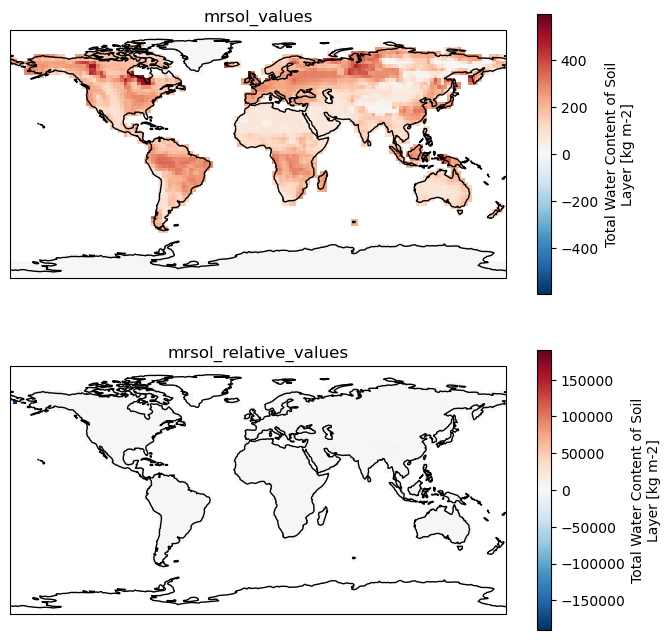

In [35]:
depth = 2


fig_global_crpss, ax = plt.subplots(
subplot_kw={"projection": ccrs.PlateCarree()},
nrows=2,
ncols=1,
figsize=(8, 8)
)
da = target_unstacked.isel(depth=depth).mean("time")["mrsol"]
da.plot(ax=ax[0])
ax[0].coastlines()
ax[0].set_title("mrsol_values")

da = (target_unstacked.mean("time")["mrsol"]/max_unstacked).isel(depth=depth)
da.plot(ax=ax[1])
ax[1].coastlines()
ax[1].set_title("mrsol_relative_values")

fig_global_crpss.show()
if safe:
    model.save.save_plot(fig_global_crpss, var = "mrsol",scen= "historical", folder = f"MPI-ESM1-2-LR/variations/mrsol_values//local{is_local_data}/month{Month_idx}", name=f"start={start},end={end},depth{depth}")
    
